<a href="https://colab.research.google.com/github/Eohabuenyi1/-Churn-Prediction/blob/main/Week1_Intern_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual homework project 1

In [2]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import data
df_web = pd.read_csv('/content/web_sessions.csv')
df_transactions = pd.read_csv('/content/transactions.csv')
df_customers = pd.read_csv('/content/customers.csv')
df_campaigns = pd.read_csv('/content/campaign_touchpoints.csv')

In [4]:
print(df_web.head(5))
print(df_transactions.head(5))
print(df_customers.head(5))
print(df_campaigns.head(5))

   session_id  customer_id  pages_viewed  time_on_site device_type  \
0           1         9716             8    271.238207     desktop   
1           2         4617             5    257.386842      mobile   
2           3         1506             4    289.679888      tablet   
3           4         3869             5    146.543376      mobile   
4           5         6245             3    339.228209      mobile   

  traffic_source session_date  converted  bounce  cart_additions  \
0        organic   2022-06-18          0       0               0   
1         social   2020-07-03          0       0               3   
2           paid   2020-12-12          0       0               3   
3         direct   2023-09-12          0       1               2   
4          email   2019-04-02          0       0               2   

   checkout_started exit_page browser  is_logged_in  
0                 0  homepage  Chrome             1  
1                 1  checkout  Chrome             1  
2       

In [5]:
df_customers.isnull().sum()
df_transactions.isnull().sum()
df_web.isnull().sum()
df_campaigns.isnull().sum()

,0
customer_id,0
campaign_id,0
touchpoint_id,0
touchpoint_date,0
clicked,0
converted,0


### Specific questions

Q1. What is the average purchase value for customers from Spain?

In [6]:
# Merge customer and transaction data
merged = pd.merge(
    df_transactions,
    df_customers[['customer_id', 'country']],
    on='customer_id',
    how='inner'
)

# Filter for customers from Spain
spain_transactions = merged[merged['country'] == 'Spain']

# Calculate average purchase value
average_purchase_value = spain_transactions['purchase_value'].mean()

print(f"Average purchase value for customers from Spain: {average_purchase_value:.2f}")

Average purchase value for customers from Spain: 230.96


Q2. What is the minimum purchase value for customers from Germany?

In [7]:
# Merge customer and transaction data
merged = pd.merge(
    df_transactions,
    df_customers[['customer_id', 'country']],
    on='customer_id',
    how='inner'
)

# Filter for customers from Germany
germany_transactions = merged[merged['country'] == 'Germany']

# Calculate minimum purchase value
min_purchase_value = germany_transactions['purchase_value'].min()

print(f"Minimum purchase value for customers from Germany: {min_purchase_value:.2f}")

Minimum purchase value for customers from Germany: 10.01


Q3. How much did males spend on buying products in the Sports category?

In [8]:
# Merge customer and transaction data
merged = pd.merge(
    df_transactions,
    df_customers[['customer_id', 'gender']],
    on='customer_id',
    how='inner'
)

# Filter for Male customers and Sports purchases
male_sports = merged[
    (merged['gender'] == 'Male') &
    (merged['product_category'] == 'Sports')
]

# Calculate total spend
total_spent = male_sports['purchase_value'].sum()

print(f"Total amount spent by males on Sports products: ${total_spent:,.2f}")

Total amount spent by males on Sports products: $0.00


Q4. What is the average age of female customers from Canada?

In [9]:
average_age = (
    df_customers[
        (df_customers['gender'] == 'Female') &
        (df_customers['country'] == 'Canada')
    ]['age']
    .dropna()
    .mean()
)

print(f"Average age of female customers from Canada: {average_age:.2f}")

Average age of female customers from Canada: 42.92


Q5. How much does an average male customer from the UK spend?

In [10]:
# Merge customer and transaction data
merged = pd.merge(
    df_transactions,
    df_customers[['customer_id', 'gender', 'country']],
    on='customer_id',
    how='inner'
)

# Filter for male customers from the UK
uk_males = merged[
    (merged['gender'] == 'Male') &
    (merged['country'] == 'UK')
]

# Calculate total spend per customer
customer_spend = (
    uk_males
    .groupby('customer_id')['purchase_value']
    .sum()
)

# Calculate average spend per customer
average_spend = customer_spend.mean()

print(f"Average spend per male customer from the UK: £{average_spend:.2f}")

Average spend per male customer from the UK: £1051.55


Q6. What is the maximum purchase value for females in the Toys category?

In [11]:
max_purchase_value = (
    df_transactions
    .merge(df_customers[['customer_id', 'gender']], on='customer_id')
    .query("gender == 'Female' and product_category == 'Toys'")
    ['purchase_value']
    .dropna()
    .max()
)

print(max_purchase_value)

nan


Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [12]:
# Filter for sessions that converted and calculate the average pages viewed
avg_pages = df_web[df_web['converted'] == 1]['pages_viewed'].mean()

print(f"Average pages viewed for successful purchases: {avg_pages:.2f}")

Average pages viewed for successful purchases: 5.73


Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [13]:
# Calculate the average time on site grouped by conversion status
avg_time = df_web.groupby('converted')['time_on_site'].mean()

print(f"Average time for non-purchasing sessions: {avg_time[0]:.2f} seconds")
print(f"Average time for purchasing sessions: {avg_time[1]:.2f} seconds")

Average time for non-purchasing sessions: 299.24 seconds
Average time for purchasing sessions: 311.19 seconds


### Visualisation tasks

Q9. Plot purchasing value across years.

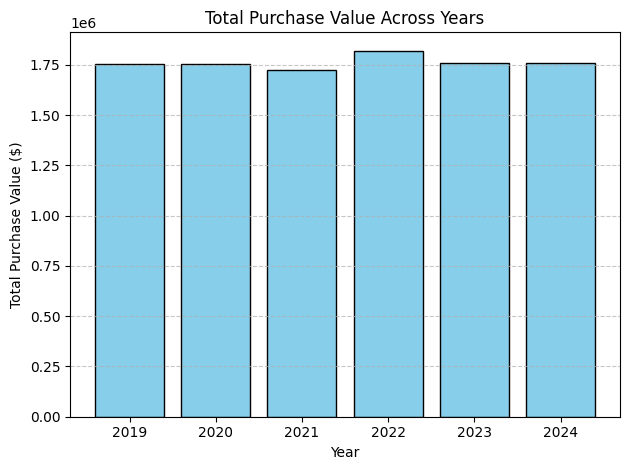

In [14]:
# Convert purchase_date to datetime and extract the year
df_transactions['purchase_date'] = pd.to_datetime(df_transactions['purchase_date'])
df_transactions['year'] = df_transactions['purchase_date'].dt.year

# Group by year and calculate total purchase value
yearly_sales = df_transactions.groupby('year')['purchase_value'].sum()

# Plot the chart (Bar Chart)
plt.bar(yearly_sales.index.astype(str), yearly_sales.values, color='skyblue', edgecolor='black')
plt.title('Total Purchase Value Across Years')
plt.xlabel('Year')
plt.ylabel('Total Purchase Value ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the chart as an image
plt.savefig('purchase_value_by_year.png')

Q10. Plot purchasing value across product categories.

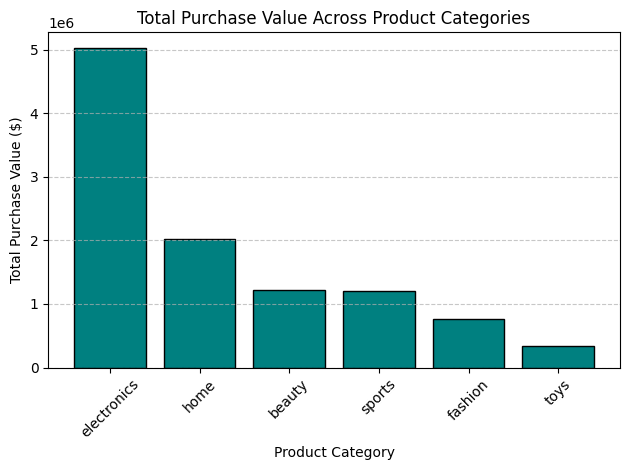

In [15]:
# Group by product category, sum the purchase value, and sort in descending order
category_sales = df_transactions.groupby('product_category')['purchase_value'].sum().sort_values(ascending=False)

# Plot the bar chart
plt.bar(category_sales.index, category_sales.values, color='teal', edgecolor='black')
plt.title('Total Purchase Value Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Total Purchase Value ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

**ADDITIONAL VISUALISATIONS**


Q11. Time on Site vs Pages Viewed

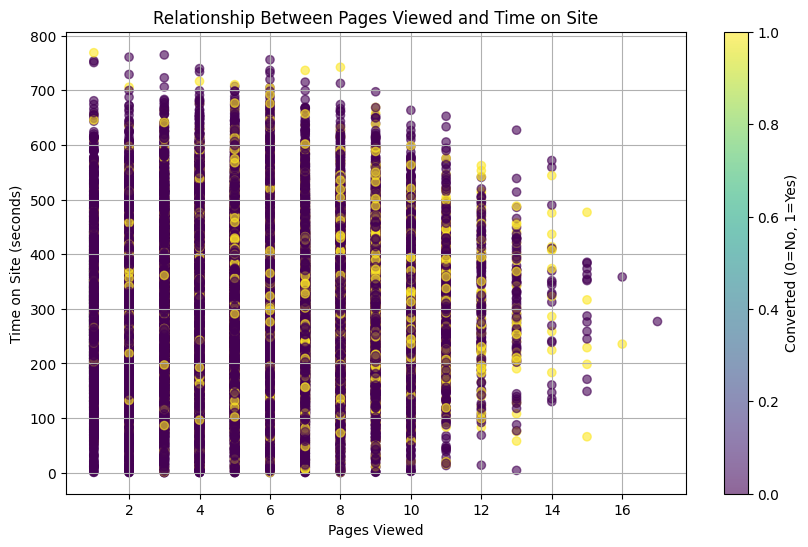

In [16]:
# Create scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_web['pages_viewed'],
    df_web['time_on_site'],
    c=df_web['converted'],
    alpha=0.6
)

plt.xlabel('Pages Viewed')
plt.ylabel('Time on Site (seconds)')
plt.title('Relationship Between Pages Viewed and Time on Site')
plt.colorbar(label='Converted (0=No, 1=Yes)')
plt.grid(True)
plt.show()

Q12. Purchase Value by Loyalty Tier

<Figure size 1000x600 with 0 Axes>

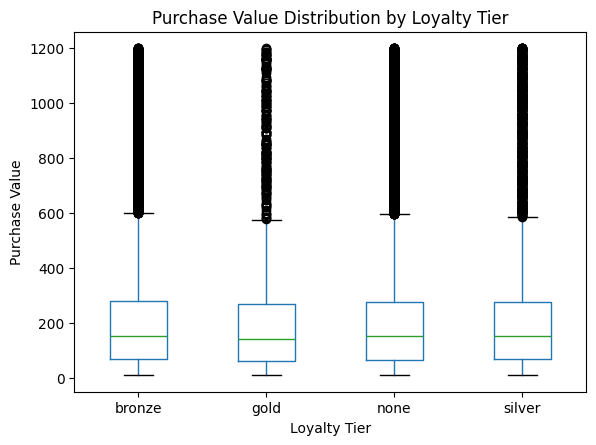

In [17]:
# Merge datasets
merged_data = df_transactions.merge(
    df_customers[['customer_id', 'loyalty_tier']],
    on='customer_id',
    how='left'
)

# Remove missing loyalty tiers if any
merged_data = merged_data.dropna(subset=['loyalty_tier'])

# Create box plot
plt.figure(figsize=(10, 6))
merged_data.boxplot(
    column='purchase_value',
    by='loyalty_tier',
    grid=False
)

plt.title('Purchase Value Distribution by Loyalty Tier')
plt.suptitle('')
plt.xlabel('Loyalty Tier')
plt.ylabel('Purchase Value')
plt.show()

Q13. Identify Three Patterns in the Data

1.  Higher website engagement is associated with a greater likelihood of conversion. Customers who viewed more pages and spent longer on the website tended to have higher conversion rates, suggesting that user engagement plays an important role in purchase decisions.

2.  Purchase behaviour differs across loyalty tiers. The box plot indicates that customers in higher loyalty tiers generally make larger purchases and exhibit different spending patterns compared to lower-tier customers, highlighting the value of customer loyalty programs.

3.   Purchase values show considerable variability within customer segments. The presence of outliers and wide distributions in the purchase data suggests that while some customers make relatively small purchases, a smaller group of customers contributes significantly larger transactions, indicating diverse purchasing behaviours across the customer base.